In [1]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

In [2]:
hmin = 100000

In [3]:
union_geom = Polygon([
    [-81.1069638967657,27.7806581362989],
    [-82.6749985417016,31.4619348745535],
    [-79.5028824783831,35.0666122192337],
    [-77.1598422043409,36.3642960633186],
    [-76.6191406026389,39.8968798611052],
    [-73.2127205119161,43.1005368511897],
    [-69.6801367141295,44.686594882849],
    [-60.848677219663,36.9365385917866],
    [-70.2568850892783,27.6725178159585],
    [-81.1069638967657,27.7806581362989],
])

In [4]:
import rasterio
import pyproj

Raster = "inputs/carolinas_Gebco.tif"

crs = pyproj.CRS.from_epsg(4326)

with rasterio.open(Raster) as src:
    zdat = src.read(1)
    x = np.arange(src.width)
    y = np.arange(src.height)
    lon = (src.transform * (x, np.zeros_like(x)))[0]
    lat = (src.transform * (np.zeros_like(y), y))[1]
    llon, llat = np.meshgrid(lon, lat)

In [5]:
from pymesh2d.geom_util.getiso import getiso_polygone

polygone_cost = getiso_polygone(llon, llat, zdat, zmax=0.0)

In [6]:
from pymesh2d.geom_util.poly_util import resample_polygon
from pymesh2d.geom_util.proj_util import get_utm_crs_from_crs, reproject_geometry

polygone_intersection_UTM = reproject_geometry(
    polygone_cost, crs, get_utm_crs_from_crs(crs)
)

polygone_intersection_resampled_UTM = resample_polygon(
    polygone_intersection_UTM, hmin
)

In [7]:
poly_bbox_UTM = reproject_geometry(union_geom, crs, get_utm_crs_from_crs(crs))
polygone_final_UTM = polygone_intersection_resampled_UTM.intersection(poly_bbox_UTM)

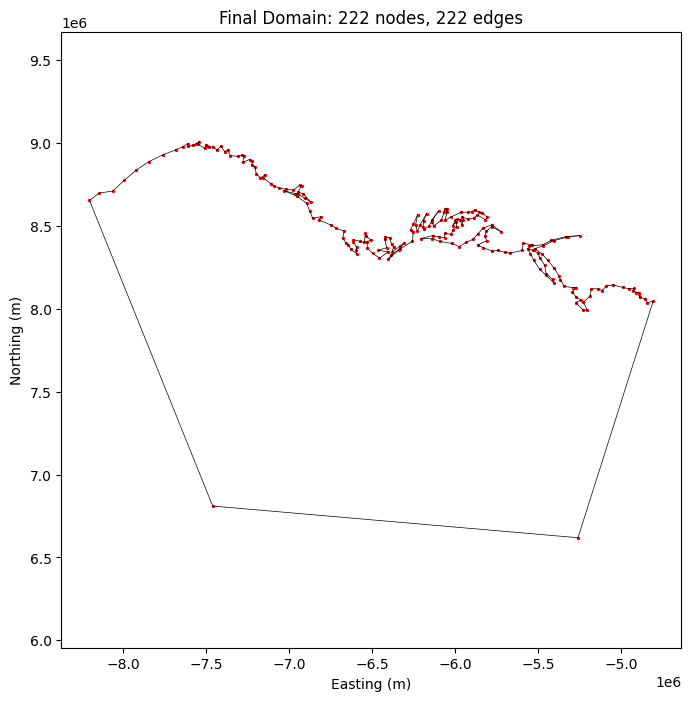

In [9]:
from pymesh2d.geom_util.poly_util import polygon_to_node_edge

node, edge = polygon_to_node_edge(polygone_final_UTM)

# Visualize the final domain
fig, ax = plt.subplots(figsize=(8, 8))

for e in edge.astype(int):
    ax.plot(node[e, 0], node[e, 1], "k-", lw=0.5)
ax.scatter(node[:, 0], node[:, 1], color="red", s=2)

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title(f"Final Domain: {len(node)} nodes, {len(edge)} edges")
ax.axis("equal");
fig.savefig('figures/Syntesis/00_Final_domain_carolinas.png', dpi=200)

In [10]:
import numpy as np
from shapely.geometry import Point
from shapely.prepared import prep
from scipy.spatial import cKDTree

def hfun_depth_quadratic(
    test,
    depth_field,
    hmin=np.inf,
    # polygon_hr=None,
    # hmin_polygon=None,
    hmax=np.inf,
):
    """
    hfun continue basée sur une équation quadratique en fonction de la profondeur :
    h = 0.14*Z^2 + 28*Z + 655

    Parameters
    ----------
    test : (N, 2) array
        Coordonnées des points.
    depth_field : callable or array
        Profondeur à chaque point.
    hmax : float
        Taille maximale autorisée.
    polygon_hr : shapely Polygon or MultiPolygon, optional
        Polygone de haute résolution.
    hmin_polygon : float, optional
        Taille minimale à l'intérieur du polygone.

    Returns
    -------
    hfun : (N,) ndarray
        Taille de maille cible continue.
    """

    if callable(depth_field):
        h = depth_field(test)
    else:
        h = np.asarray(depth_field)
        if h.size == 1:
            h = np.full(test.shape[0], h)
        elif h.shape[0] != test.shape[0]:
            raise ValueError("depth_field must match number of test points")

    hfun = 0.14 * h**2 + 28 * h + 655

    hfun = np.maximum(hfun, hmin)
    hfun = np.minimum(hfun, hmax)

    return hfun


In [11]:
from pymesh2d.geomesh_util.depth_field import depth_field_from_tif

depth_field = depth_field_from_tif(
    Raster, output_crs=get_utm_crs_from_crs(crs)
)

def hfun(test):
    return hfun_depth_quadratic(test,depth_field,hmin=hmin, hmax = 16384)


In [12]:
from pymesh2d.refine import refine
from pymesh2d.smooth import smooth

opts = {"kind": "delaunay"}

vert_ll, etri, tria, tnum = refine(node, edge, [], opts, hfun)
vert_ll, etri, tria, tnum = smooth(vert_ll, etri, tria, tnum)


 Refine triangulation...

 -------------------------------------------------------
      |ITER.|          |CDT1(X)|          |CDT2(X)|     
 -------------------------------------------------------
         10               1194                248
         11               1195                248
         20               1290               2474
         30               1317              18191
         40               1317              46901
         41               1317              46917


 Smooth triangulation...

 -------------------------------------------------------
      |ITER.|          |MOVE(X)|          |DTRI(X)|     
 -------------------------------------------------------
          0              22057              45063
          4              17594              44612
          8               9715              44612
         12               1275              44612
         16                161              44612
         20                 40              44612
   

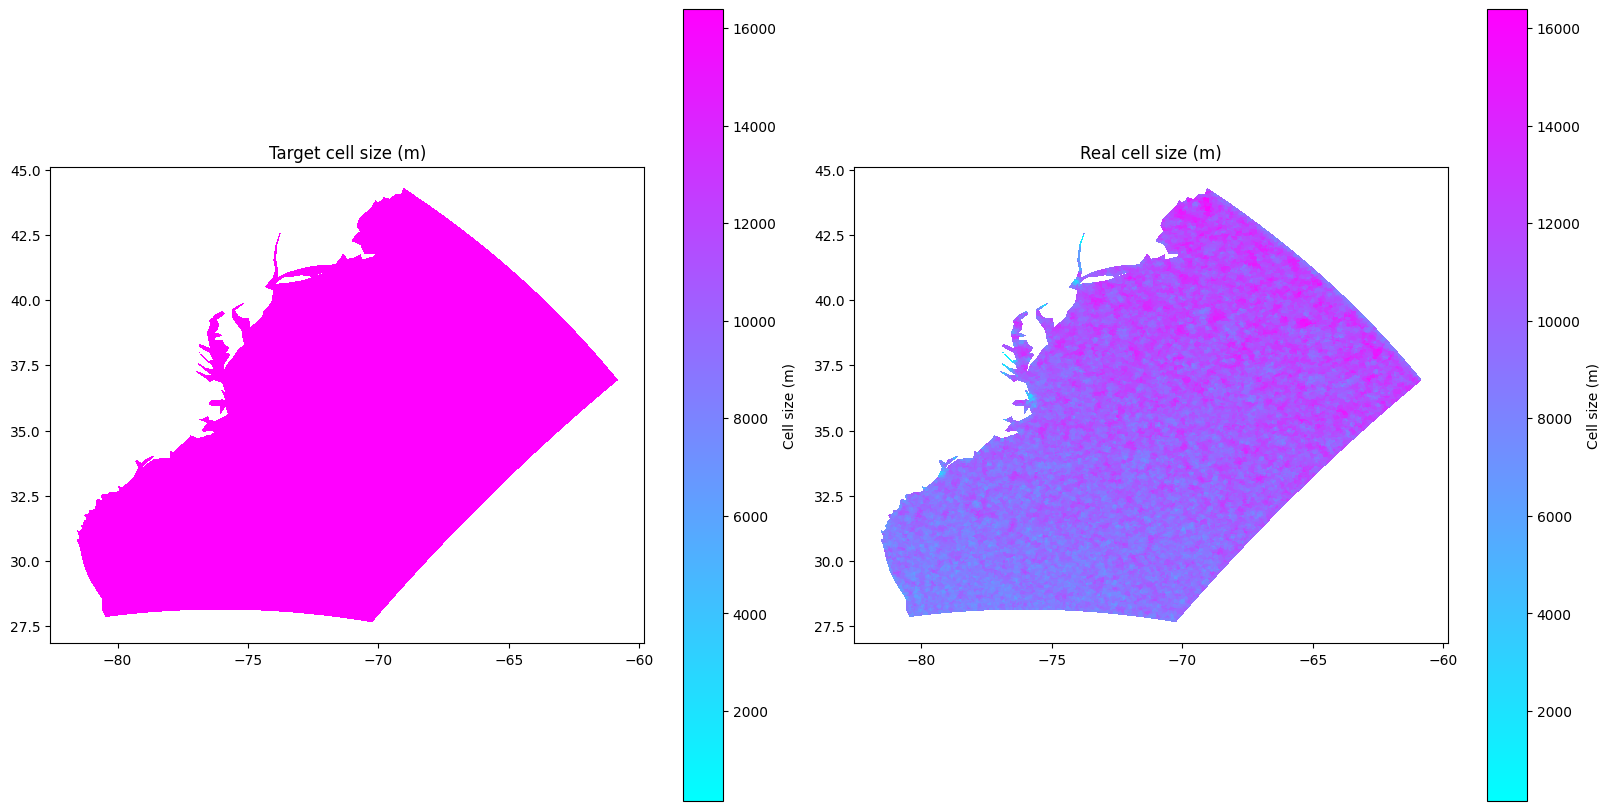

In [14]:
from pyproj import Geod
import numpy as np
import matplotlib.pyplot as plt

from pymesh2d.geom_util.proj_util import reproject_node

# Reprojection
vert = reproject_node(vert_ll, get_utm_crs_from_crs(crs), crs)

X = vert[:, 0][tria.astype(int)]
Y = vert[:, 1][tria.astype(int)]

geod = Geod(ellps="WGS84")

lon1, lon2, lon3 = X[:, 0], X[:, 1], X[:, 2]
lat1, lat2, lat3 = Y[:, 0], Y[:, 1], Y[:, 2]

_, _, d12 = geod.inv(lon1, lat1, lon2, lat2)
_, _, d23 = geod.inv(lon2, lat2, lon3, lat3)
_, _, d31 = geod.inv(lon3, lat3, lon1, lat1)

# Taille réelle des cellules
facecolor_real = (d12 + d23 + d31) / 3.0

# Taille cible
facecolor_target = np.mean(hfun(vert)[tria[:, :3]], axis=1)

# Échelle commune
vmin = min(facecolor_real.min(), facecolor_target.min())
vmax = max(facecolor_real.max(), facecolor_target.max())

# Figure
fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)

# --- Target mesh size ---
tpc0 = axes[0].tripcolor(
    vert[:, 0],
    vert[:, 1],
    tria[:, :3],
    facecolors=facecolor_target,
    cmap="cool",
    vmin=vmin,
    vmax=vmax,
)
axes[0].set_aspect("equal")
axes[0].set_title("Target cell size (m)")
fig.colorbar(tpc0, ax=axes[0], label="Cell size (m)")

# --- Real mesh size ---
tpc1 = axes[1].tripcolor(
    vert[:, 0],
    vert[:, 1],
    tria[:, :3],
    facecolors=facecolor_real,
    cmap="cool",
    vmin=vmin,
    vmax=vmax,
)
axes[1].set_aspect("equal")
axes[1].set_title("Real cell size (m)")
fig.colorbar(tpc1, ax=axes[1], label="Cell size (m)")

fig.savefig('figures/Syntesis/00_Comparison_target_real_cell_size_carolinas.png', dpi=200)


Number of elements 44612
Number of nodes 22965


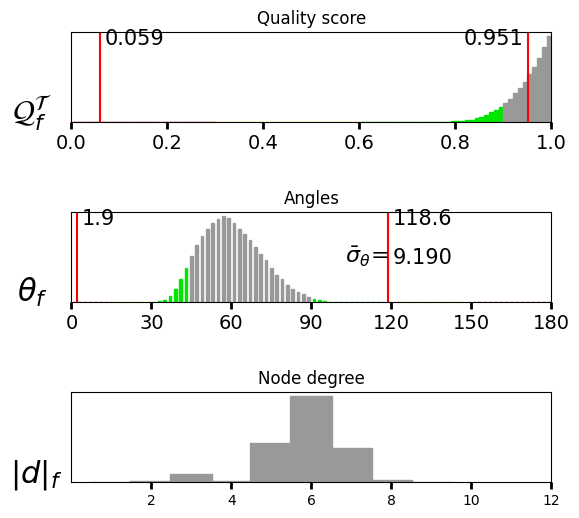

In [15]:
from pymesh2d.tricost import tricost

print(f"Number of elements {tria.shape[0]}")
print(f"Number of nodes {vert.shape[0]}")

tricost(vert, tria[:, :3], tria, tnum)
plt.savefig('figures/Syntesis/00_Triangulation_quality_carolinas.png', dpi=200)

In [16]:
from pymesh2d.geomesh_util.interpolation_mesh import interpolate_from_tiff

# Interpolate bathymetry onto mesh vertices
z = interpolate_from_tiff(Raster, vert, crs)

In [17]:
# from pymesh2d.geomesh_util.grd_util import adcirc2DFlowFM

# # Export to NetCDF format
# adcirc2DFlowFM(np.column_stack((vert, z)), tria, "templates/mesh_Carolinas.nc")

In [18]:
from pymesh2d.geomesh_util.border_util import identify_boundary

# Identify boundary types (open ocean vs land)
edge_tag, edge_open, edge_land = identify_boundary(vert, tria, z, zlim=20)

In [19]:
from pymesh2d.geomesh_util.grd_util import export_to_grd

# Export to GRD format with boundaries
export_to_grd(
    "templates/fort.14",
    vert=vert,
    tria=tria,
    z=z,
    crs=crs,
    edge_tag=edge_tag,
    edge_open=edge_open,
    edge_land=edge_land,
)

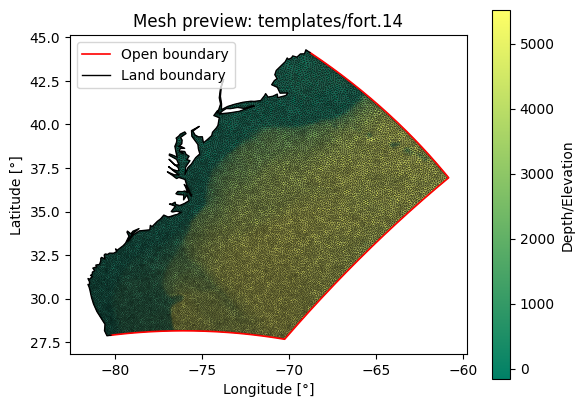

In [21]:
from pymesh2d.geomesh_util.grd_util import plot_grd

# Visualize final grid with boundary classification
plot_grd("templates/fort.14", show_boundaries=True)
plt.savefig('figures/Syntesis/00_Final_grid_with_boundaries_carolinas.png', dpi=200)